뇌졸중(Stroke) 예측

1) 데이터 불러오기 & 전처리 & 함수 정의
2) 모델 만들기
    1) 모델 종류: Decision Tree, Random Forest, Extra Tree, GBM, HGBM, XGBoost, LightGBM, Logistic Regression (Ridge, Lasso)
    2) 기본 모델 훈련 & 평가 + cross_validate
    3) GridSearchCV 최적 파라미터 탐색
    4) 최적 파라미터로 재훈련 & 최종 평가 + feature importance
    5) Early Stopping 적용 (XGBoost, LightGBM만)
3) 시각화
    1) 전체 모델 비교
    2) LightGBM vs RandomForest
    3) RandomForest
4) 가상 데이터 예측

# 0. 데이터 불러오기 & 전처리 & 함수 정의

In [1]:
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import koreanize_matplotlib
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 데이터 불러오기
df = pd.read_csv('stroke_dataset.csv')
print(df.shape)
#display(df.head())
display(df.info())
#display(df.describe())

(70000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Chest Pain                      70000 non-null  int64  
 1   Shortness of Breath             70000 non-null  int64  
 2   Irregular Heartbeat             70000 non-null  int64  
 3   Fatigue & Weakness              70000 non-null  int64  
 4   Dizziness                       70000 non-null  int64  
 5   Swelling (Edema)                70000 non-null  int64  
 6   Pain in Neck/Jaw/Shoulder/Back  70000 non-null  int64  
 7   Excessive Sweating              70000 non-null  int64  
 8   Persistent Cough                70000 non-null  int64  
 9   Nausea/Vomiting                 70000 non-null  int64  
 10  High Blood Pressure             70000 non-null  int64  
 11  Chest Discomfort (Activity)     70000 non-null  int64  
 12  Cold Hands/Feet     

None

In [3]:
# 데이터 전처리

# At Risk (Binary) 컬럼 제거
df = df.drop(['Stroke Risk (%)'], axis=1)
#print(df.info())

# 'Age' >= 65 이상인 행들만 분리
stroke_df = df[df['Age'] >= 65]
print(stroke_df.shape)
print(stroke_df.info())
#display(stroke_df.head())

# 피처 세트와 레이블 세트로 분리
X_feature = stroke_df.iloc[:, :-1]
y_label = stroke_df.iloc[:, -1]
#display(X_feature.head())
#display(y_label.head())

# 클래스 불균형 확인
print('\n=== 클래스 분포 ===')
print(y_label.value_counts())
print(y_label.value_counts(normalize=True))

# 전체 데이터 중 80%는 학습용, 20%는 테스트용 데이터
X_train, X_test, y_train, y_test = train_test_split(X_feature, y_label, test_size=0.2, random_state=0)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# 학습 데이터 중 90%는 학습용, 10%는 검증용 데이터 (XGBoost/LightGBM Early Stopping 용도)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=0)
print(X_tr.shape, X_val.shape, y_tr.shape, y_val.shape)

# StandardScaler 클래스를 사용해 훈련 세트 전처리와 테스트 세트 변환
# Logistic Regression에서 사용
ss = StandardScaler()
ss.fit(X_train)
X_train_scaled = ss.transform(X_train)
X_test_scaled = ss.transform(X_test)

# XGBoost scale_pos_weight 계산 (클래스 불균형 보정)
# 0 클래스 수 / 1 클래스 수
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f'\nscale_pos_weight: {scale:.4f}')

(24989, 17)
<class 'pandas.core.frame.DataFrame'>
Index: 24989 entries, 6 to 69999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Chest Pain                      24989 non-null  int64
 1   Shortness of Breath             24989 non-null  int64
 2   Irregular Heartbeat             24989 non-null  int64
 3   Fatigue & Weakness              24989 non-null  int64
 4   Dizziness                       24989 non-null  int64
 5   Swelling (Edema)                24989 non-null  int64
 6   Pain in Neck/Jaw/Shoulder/Back  24989 non-null  int64
 7   Excessive Sweating              24989 non-null  int64
 8   Persistent Cough                24989 non-null  int64
 9   Nausea/Vomiting                 24989 non-null  int64
 10  High Blood Pressure             24989 non-null  int64
 11  Chest Discomfort (Activity)     24989 non-null  int64
 12  Cold Hands/Feet                 24989 non-null  int64

In [4]:
# 모델 예측 성능 평가 함수
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    print(f'정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}')

#get_clf_eval(y_test, preds, pred_probs)

# 1. Classification

### 1-1. Decision Tree

In [5]:
# [1단계] 기본 모델 훈련 & 평가
dt = DecisionTreeClassifier(random_state=0, class_weight='balanced')
dt.fit(X_train, y_train)
dt_train_score = dt.score(X_train, y_train)
dt_test_score = dt.score(X_test, y_test)
print(f'dt_train_score: {dt_train_score}')
print(f'dt_test_score: {dt_test_score}')

dt_pred = dt.predict(X_test)
print(f'dt_pred: {dt_pred}')

dt_pred_proba = dt.predict_proba(X_test)[:, 1]
print(f'dt_pred_proba: {dt_pred_proba}')

get_clf_eval(y_test, dt_pred, dt_pred_proba)

# cross_validate
scores = cross_validate(dt, X_train, y_train, return_train_score=True, n_jobs=-1)
print(f'[CV] train: {np.mean(scores["train_score"]):.4f}, val: {np.mean(scores["test_score"]):.4f}')

dt_train_score: 1.0
dt_test_score: 0.9551820728291317
dt_pred: [1 1 1 ... 1 1 1]
dt_pred_proba: [1. 1. 1. ... 1. 1. 1.]
오차 행렬
[[ 104  119]
 [ 105 4670]]
정확도: 0.9552, 정밀도: 0.9752, 재현율: 0.9780, F1: 0.9766, AUC: 0.7222
[CV] train: 1.0000, val: 0.9536


In [6]:
# [2단계] GridSearchCV
params = {'min_impurity_decrease': np.arange(0.0001, 0.001, 0.0001),
          'max_depth':             range(5, 20, 1),
          'min_samples_split':     range(2, 100, 10)}

gs = GridSearchCV(DecisionTreeClassifier(random_state=0, class_weight='balanced'), params, n_jobs=-1)
gs.fit(X_train, y_train)
print(f'최적 파라미터: {gs.best_params_}')
print(f'최고 CV 점수: {np.max(gs.cv_results_["mean_test_score"]):.4f}')

최적 파라미터: {'max_depth': 14, 'min_impurity_decrease': np.float64(0.0001), 'min_samples_split': 2}
최고 CV 점수: 0.9299


In [7]:
# [3단계] 최적 파라미터로 재훈련
dt = DecisionTreeClassifier(random_state=0, class_weight='balanced', **gs.best_params_)
dt.fit(X_train, y_train)
dt_train_score = dt.score(X_train, y_train)
dt_test_score = dt.score(X_test, y_test)
print(f'[튜닝 후] dt_train_score: {dt_train_score}')
print(f'[튜닝 후] dt_test_score: {dt_test_score}')

dt_pred = dt.predict(X_test)
print(f'dt_pred: {dt_pred}')

dt_pred_proba = dt.predict_proba(X_test)[:, 1]
print(f'dt_pred_proba: {dt_pred_proba}')

get_clf_eval(y_test, dt_pred, dt_pred_proba)

# 특성 중요도
print(f'특성 중요도:\n{dt.feature_importances_}')

[튜닝 후] dt_train_score: 0.9548296733530088
[튜닝 후] dt_test_score: 0.9217687074829932
dt_pred: [1 1 1 ... 1 1 1]
dt_pred_proba: [0.99176061 0.99176061 1.         ... 0.93321708 0.99176061 0.98379626]
오차 행렬
[[ 149   74]
 [ 317 4458]]
정확도: 0.9218, 정밀도: 0.9837, 재현율: 0.9336, F1: 0.9580, AUC: 0.7477
특성 중요도:
[0.07299692 0.04795234 0.02959577 0.05626156 0.05171679 0.03545203
 0.04017348 0.05776528 0.0436979  0.03381676 0.03249646 0.06789754
 0.03820259 0.06625389 0.06310423 0.26261644]


### 1-2. Random Forest

In [8]:
# [1단계] 기본 모델 훈련 & 평가
rf = RandomForestClassifier(random_state=0, class_weight='balanced')
rf.fit(X_train, y_train)
rf_train_score = rf.score(X_train, y_train)
rf_test_score = rf.score(X_test, y_test)
print(f'rf_train_score: {rf_train_score}')
print(f'rf_test_score: {rf_test_score}')

rf_pred = rf.predict(X_test)
print(f'rf_pred: {rf_pred}')

rf_pred_proba = rf.predict_proba(X_test)[:, 1]
print(f'rf_pred_proba: {rf_pred_proba}')

get_clf_eval(y_test, rf_pred, rf_pred_proba)

# cross_validate
scores = cross_validate(rf, X_train, y_train, return_train_score=True, n_jobs=-1)
print(f'[CV] train: {np.mean(scores["train_score"]):.4f}, val: {np.mean(scores["test_score"]):.4f}')

rf_train_score: 1.0
rf_test_score: 0.969187675070028
rf_pred: [1 1 1 ... 1 1 1]
rf_pred_proba: [1. 1. 1. ... 1. 1. 1.]
오차 행렬
[[  70  153]
 [   1 4774]]
정확도: 0.9692, 정밀도: 0.9689, 재현율: 0.9998, F1: 0.9841, AUC: 0.9911
[CV] train: 1.0000, val: 0.9707


In [9]:
# [2단계] GridSearchCV
params = {'min_impurity_decrease': np.arange(0.0001, 0.001, 0.0001),
          'max_depth':             range(5, 20, 1),
          'min_samples_split':     range(2, 100, 10)}

gs = GridSearchCV(RandomForestClassifier(random_state=0, class_weight='balanced'), params, n_jobs=-1)
gs.fit(X_train, y_train)
print(f'최적 파라미터: {gs.best_params_}')
print(f'최고 CV 점수: {np.max(gs.cv_results_["mean_test_score"]):.4f}')

최적 파라미터: {'max_depth': 14, 'min_impurity_decrease': np.float64(0.0001), 'min_samples_split': 2}
최고 CV 점수: 0.9789


In [10]:
# [3단계] 최적 파라미터로 재훈련
rf = RandomForestClassifier(random_state=0, class_weight='balanced', **gs.best_params_)
rf.fit(X_train, y_train)
rf_train_score = rf.score(X_train, y_train)
rf_test_score = rf.score(X_test, y_test)
print(f'[튜닝 후] rf_train_score: {rf_train_score}')
print(f'[튜닝 후] rf_test_score: {rf_test_score}')

rf_pred = rf.predict(X_test)
print(f'rf_pred: {rf_pred}')

rf_pred_proba = rf.predict_proba(X_test)[:, 1]
print(f'rf_pred_proba: {rf_pred_proba}')

get_clf_eval(y_test, rf_pred, rf_pred_proba)

# 특성 중요도
print(f'특성 중요도:\n{rf.feature_importances_}')

[튜닝 후] rf_train_score: 0.9905957680956431
[튜닝 후] rf_test_score: 0.9747899159663865
rf_pred: [1 1 1 ... 1 1 1]
rf_pred_proba: [0.99329037 0.9926828  0.8892251  ... 0.96237954 0.9825878  0.99041304]
오차 행렬
[[ 172   51]
 [  75 4700]]
정확도: 0.9748, 정밀도: 0.9893, 재현율: 0.9843, F1: 0.9868, AUC: 0.9909
특성 중요도:
[0.05964373 0.04598122 0.05019616 0.06709885 0.04636192 0.05071673
 0.04369378 0.05099245 0.04352371 0.04198927 0.04897318 0.05555037
 0.05365146 0.05936507 0.06021145 0.22205065]


### 1-3. Extra Tree

In [11]:
# [1단계] 기본 모델 훈련 & 평가
et = ExtraTreesClassifier(n_jobs=-1, random_state=0, class_weight='balanced')
et.fit(X_train, y_train)
et_train_score = et.score(X_train, y_train)
et_test_score = et.score(X_test, y_test)
print(f'et_train_score: {et_train_score}')
print(f'et_test_score: {et_test_score}')

et_pred = et.predict(X_test)
print(f'et_pred: {et_pred}')

et_pred_proba = et.predict_proba(X_test)[:, 1]
print(f'et_pred_proba: {et_pred_proba}')

get_clf_eval(y_test, et_pred, et_pred_proba)

# cross_validate
scores = cross_validate(et, X_train, y_train, return_train_score=True, n_jobs=-1)
print(f'[CV] train: {np.mean(scores["train_score"]):.4f}, val: {np.mean(scores["test_score"]):.4f}')

et_train_score: 1.0
et_test_score: 0.9707883153261304
et_pred: [1 1 1 ... 1 1 1]
et_pred_proba: [1.   1.   0.99 ... 1.   1.   1.  ]
오차 행렬
[[  88  135]
 [  11 4764]]
정확도: 0.9708, 정밀도: 0.9724, 재현율: 0.9977, F1: 0.9849, AUC: 0.9868
[CV] train: 1.0000, val: 0.9727


In [12]:
# [2단계] GridSearchCV
params = {'min_impurity_decrease': np.arange(0.0001, 0.001, 0.0001),
          'max_depth':             range(5, 20, 1),
          'min_samples_split':     range(2, 100, 10)}

gs = GridSearchCV(ExtraTreesClassifier(n_jobs=-1, random_state=0, class_weight='balanced'), params, n_jobs=-1)
gs.fit(X_train, y_train)
print(f'최적 파라미터: {gs.best_params_}')
print(f'최고 CV 점수: {np.max(gs.cv_results_["mean_test_score"]):.4f}')

최적 파라미터: {'max_depth': 15, 'min_impurity_decrease': np.float64(0.0001), 'min_samples_split': 2}
최고 CV 점수: 0.9659


In [13]:
# [3단계] 최적 파라미터로 재훈련
et = ExtraTreesClassifier(n_jobs=-1, random_state=0, class_weight='balanced', **gs.best_params_)
et.fit(X_train, y_train)
et_train_score = et.score(X_train, y_train)
et_test_score = et.score(X_test, y_test)
print(f'[튜닝 후] et_train_score: {et_train_score}')
print(f'[튜닝 후] et_test_score: {et_test_score}')

et_pred = et.predict(X_test)
print(f'et_pred: {et_pred}')

et_pred_proba = et.predict_proba(X_test)[:, 1]
print(f'et_pred_proba: {et_pred_proba}')

get_clf_eval(y_test, et_pred, et_pred_proba)

# 특성 중요도
print(f'특성 중요도:\n{et.feature_importances_}')

[튜닝 후] et_train_score: 0.9746886098744435
[튜닝 후] et_test_score: 0.9655862344937975
et_pred: [1 1 1 ... 1 1 1]
et_pred_proba: [0.99240559 0.98475109 0.83641394 ... 0.92562238 0.97167592 0.98979773]
오차 행렬
[[ 194   29]
 [ 143 4632]]
정확도: 0.9656, 정밀도: 0.9938, 재현율: 0.9701, F1: 0.9818, AUC: 0.9868
특성 중요도:
[0.0685712  0.05110506 0.05055817 0.07503475 0.04836724 0.05132658
 0.04704347 0.05896132 0.04885765 0.04503924 0.0481316  0.0693848
 0.06062222 0.06818685 0.07586679 0.13294307]


### 1-4. GBM(Gradient Boosting Machine)

In [14]:
# [1단계] 기본 모델 훈련 & 평가
# GradientBoostingClassifier는 class_weight를 지원하지 않음
gb = GradientBoostingClassifier(random_state=0)
gb.fit(X_train, y_train)
gb_train_score = gb.score(X_train, y_train)
gb_test_score = gb.score(X_test, y_test)
print(f'gb_train_score: {gb_train_score}')
print(f'gb_test_score: {gb_test_score}')

gb_pred = gb.predict(X_test)
print(f'gb_pred: {gb_pred}')

gb_pred_proba = gb.predict_proba(X_test)[:, 1]
print(f'gb_pred_proba: {gb_pred_proba}')

get_clf_eval(y_test, gb_pred, gb_pred_proba)

# cross_validate
scores = cross_validate(gb, X_train, y_train, return_train_score=True, n_jobs=-1)
print(f'[CV] train: {np.mean(scores["train_score"]):.4f} val: {np.mean(scores["test_score"]):.4f}')

gb_train_score: 0.9782902306037717
gb_test_score: 0.9731892757102841
gb_pred: [1 1 1 ... 1 1 1]
gb_pred_proba: [0.99992289 0.99987191 0.95757585 ... 0.9955632  0.99639004 0.99973303]
오차 행렬
[[  89  134]
 [   0 4775]]
정확도: 0.9732, 정밀도: 0.9727, 재현율: 1.0000, F1: 0.9862, AUC: 0.9985
[CV] train: 0.9791 val: 0.9738


In [15]:
# [2단계] GridSearchCV
params = {'n_estimators':   [100, 200, 300],
          'learning_rate':  [0.05, 0.1, 0.2],
          'max_depth':      range(3, 8, 1)}

gs = GridSearchCV(GradientBoostingClassifier(random_state=0), params, n_jobs=-1)
gs.fit(X_train, y_train)
print(f'최적 파라미터: {gs.best_params_}')
print(f'최고 CV 점수: {np.max(gs.cv_results_["mean_test_score"]):.4f}')

최적 파라미터: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300}
최고 CV 점수: 0.9981


In [16]:
# [3단계] 최적 파라미터로 재훈련
gb = GradientBoostingClassifier(random_state=0, **gs.best_params_)
gb.fit(X_train, y_train)
gb_train_score = gb.score(X_train, y_train)
gb_test_score = gb.score(X_test,  y_test)
print(f'[튜닝 후] gb_train_score: {gb_train_score}')
print(f'[튜닝 후] gb_test_score: {gb_test_score}')

gb_pred = gb.predict(X_test)
print(f'gb_pred: {gb_pred}')

gb_pred_proba = gb.predict_proba(X_test)[:, 1]
print(f'gb_pred_proba: {gb_pred_proba}')

get_clf_eval(y_test, gb_pred, gb_pred_proba)

print(f'특성 중요도:\n{gb.feature_importances_}')

[튜닝 후] gb_train_score: 0.9999499774898705
[튜닝 후] gb_test_score: 0.9997999199679872
gb_pred: [1 1 1 ... 1 1 1]
gb_pred_proba: [1.         1.         0.99662662 ... 0.99999977 0.99999535 1.        ]
오차 행렬
[[ 222    1]
 [   0 4775]]
정확도: 0.9998, 정밀도: 0.9998, 재현율: 1.0000, F1: 0.9999, AUC: 1.0000
특성 중요도:
[0.06632148 0.04437951 0.04398949 0.06388032 0.05640808 0.0464971
 0.04574855 0.04949953 0.05174173 0.04076427 0.0457924  0.05898386
 0.05800592 0.07354414 0.05988364 0.19455997]


### 1-5. Histogram-based Gradient Boosting

In [17]:
# [1단계] 기본 모델 훈련 & 평가
hgb = HistGradientBoostingClassifier(random_state=0, class_weight='balanced')
hgb.fit(X_train, y_train)
hgb_train_score = hgb.score(X_train, y_train)
hgb_test_score = hgb.score(X_test, y_test)
print(f'hgb_train_score: {hgb_train_score}')
print(f'hgb_test_score: {hgb_test_score}')

hgb_pred = hgb.predict(X_test)
print(f'hgb_pred: {hgb_pred}')

hgb_pred_proba = hgb.predict_proba(X_test)[:, 1]
print(f'hgb_pred_proba: {hgb_pred_proba}')

get_clf_eval(y_test, hgb_pred, hgb_pred_proba)

# cross_validate
scores = cross_validate(hgb, X_train, y_train, return_train_score=True, n_jobs=-1)
print(f'[CV] train: {np.mean(scores["train_score"]):.4f}, val: {np.mean(scores["test_score"]):.4f}')

hgb_train_score: 0.9798909509279176
hgb_test_score: 0.9709883953581433
hgb_pred: [1 1 1 ... 1 1 1]
hgb_pred_proba: [0.99990687 0.99992448 0.88366614 ... 0.997426   0.99778461 0.99991441]
오차 행렬
[[ 212   11]
 [ 134 4641]]
정확도: 0.9710, 정밀도: 0.9976, 재현율: 0.9719, F1: 0.9846, AUC: 0.9948
[CV] train: 0.9836, val: 0.9707


In [18]:
# [2단계] GridSearchCV
params = {'max_iter':      [100, 200, 300],
          'learning_rate': [0.05, 0.1, 0.2],
          'max_depth':     [3, 5, 7, None]}

gs = GridSearchCV(
    HistGradientBoostingClassifier(random_state=0, class_weight='balanced'), params, n_jobs=-1)
gs.fit(X_train, y_train)
print(f'최적 파라미터: {gs.best_params_}')
print(f'최고 CV 점수: {np.max(gs.cv_results_["mean_test_score"]):.4f}')

최적 파라미터: {'learning_rate': 0.2, 'max_depth': 3, 'max_iter': 300}
최고 CV 점수: 0.9872


In [19]:
# [3단계] 최적 파라미터로 재훈련
hgb = HistGradientBoostingClassifier(random_state=0, class_weight='balanced', **gs.best_params_)
hgb.fit(X_train, y_train)
hgb_train_score = hgb.score(X_train, y_train)
hgb_test_score  = hgb.score(X_test,  y_test)
print(f'[튜닝 후] hgb_train_score: {hgb_train_score}')
print(f'[튜닝 후] hgb_test_score: {hgb_test_score}')

hgb_pred = hgb.predict(X_test)
print(f'hgb_pred: {hgb_pred}')

hgb_pred_proba = hgb.predict_proba(X_test)[:, 1]
print(f'hgb_pred_proba: {hgb_pred_proba}')

get_clf_eval(y_test, hgb_pred, hgb_pred_proba)

# HistGradientBoostingClassifier는 feature_importances_ 미지원
print('※ HistGradientBoostingClassifier는 feature_importances_ 미지원')

[튜닝 후] hgb_train_score: 0.9955479965984693
[튜닝 후] hgb_test_score: 0.9901960784313726
hgb_pred: [1 1 1 ... 1 1 1]
hgb_pred_proba: [1.         1.         0.99643862 ... 0.99999982 0.99999969 1.        ]
오차 행렬
[[ 223    0]
 [  49 4726]]
정확도: 0.9902, 정밀도: 1.0000, 재현율: 0.9897, F1: 0.9948, AUC: 1.0000
※ HistGradientBoostingClassifier는 feature_importances_ 미지원


### 1-6. XGBoost(eXtra Gradient Boost)

In [20]:
# [1단계] 기본 모델 훈련 & 평가
# Warning 메시지를 없애기 위해 eval_metric 값을 XGBClassifier 생성 인자로 입력
xgb = XGBClassifier(random_state=0, n_estimators=400, learning_rate=0.1, max_depth=3, eval_metric='logloss', scale_pos_weight=scale)
xgb.fit(X_train, y_train, verbose=False)
xgb_train_score = xgb.score(X_train, y_train)
xgb_test_score = xgb.score(X_test, y_test)
print(f'xgb_train_score: {xgb_train_score}')
print(f'xgb_test_score: {xgb_test_score}')

xgb_pred = xgb.predict(X_test)
print(f'xgb_pred: {xgb_pred}')

xgb_pred_proba = xgb.predict_proba(X_test)[:, 1]
print(f'xgb_pred_proba: {xgb_pred_proba}')

get_clf_eval(y_test, xgb_pred, xgb_pred_proba)

# cross_validate
scores = cross_validate(xgb, X_train, y_train, return_train_score=True, n_jobs=-1)
print(f'[CV] train: {np.mean(scores["train_score"]):.4f}, val: {np.mean(scores["test_score"]):.4f}')

xgb_train_score: 0.9804411985393428
xgb_test_score: 0.9737895158063226
xgb_pred: [1 1 1 ... 1 1 1]
xgb_pred_proba: [1.        1.        0.9447933 ... 0.9998375 0.99992   1.       ]
오차 행렬
[[ 223    0]
 [ 131 4644]]
정확도: 0.9738, 정밀도: 1.0000, 재현율: 0.9726, F1: 0.9861, AUC: 1.0000
[CV] train: 0.9811, val: 0.9747


In [21]:
# [2단계] GridSearchCV
# GridSearch 시에는 early_stopping_rounds 제거
params = {'n_estimators':  [100, 200, 400],
          'learning_rate': [0.05, 0.1, 0.2],
          'max_depth':     [3, 5, 7]}

gs = GridSearchCV(XGBClassifier(random_state=0, eval_metric='logloss', scale_pos_weight=scale), params, n_jobs=-1)
gs.fit(X_train, y_train)
print(f'최적 파라미터: {gs.best_params_}')
print(f'최고 CV 점수: {np.max(gs.cv_results_["mean_test_score"]):.4f}')

최적 파라미터: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 400}
최고 CV 점수: 0.9927


In [22]:
# [3단계] 최적 파라미터로 재훈련
xgb = XGBClassifier(random_state=0, eval_metric='logloss', scale_pos_weight=scale, **gs.best_params_)
xgb.fit(X_train, y_train, verbose=False)
xgb_train_score = xgb.score(X_train, y_train)
xgb_test_score = xgb.score(X_test, y_test)
print(f'[튜닝 후] xgb_train_score: {xgb_train_score}')
print(f'[튜닝 후] xgb_test_score: {xgb_test_score}')

xgb_pred = xgb.predict(X_test)
print(f'xgb_pred: {xgb_pred}')

xgb_pred_proba = xgb.predict_proba(X_test)[:, 1]
print(f'xgb_pred_proba: {xgb_pred_proba}')

get_clf_eval(y_test, xgb_pred, xgb_pred_proba)

print(f'특성 중요도:\n{xgb.feature_importances_}')

[튜닝 후] xgb_train_score: 0.9997498874493522
[튜닝 후] xgb_test_score: 0.9931972789115646
xgb_pred: [1 1 1 ... 1 1 1]
xgb_pred_proba: [1.         1.         0.9980337  ... 0.9999982  0.99999964 1.        ]
오차 행렬
[[ 218    5]
 [  29 4746]]
정확도: 0.9932, 정밀도: 0.9989, 재현율: 0.9939, F1: 0.9964, AUC: 0.9997
특성 중요도:
[0.0727558  0.05874037 0.05139893 0.08537155 0.06872713 0.06020742
 0.04945375 0.05134897 0.05511263 0.05884603 0.06594622 0.07962476
 0.05654918 0.0610112  0.07684138 0.04806466]


In [23]:
# [4단계] Early Stopping 적용 (XGBoost 전용)
xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3, early_stopping_rounds=10, eval_metric='logloss', scale_pos_weight=scale)
evals = [(X_tr, y_tr), (X_val, y_val)]
xgb_wrapper.fit(X_tr, y_tr, eval_set=evals, verbose=False)

ws10_preds = xgb_wrapper.predict(X_test)
ws10_preds_proba = xgb_wrapper.predict_proba(X_test)[:, 1]
get_clf_eval(y_test, ws10_preds, ws10_preds_proba)

오차 행렬
[[ 223    0]
 [ 127 4648]]
정확도: 0.9746, 정밀도: 1.0000, 재현율: 0.9734, F1: 0.9865, AUC: 0.9999


### 1-7. LightGBM

In [24]:
# [1단계] 기본 모델 훈련 & 평가
# 기본 훈련 시에는 early_stopping_rounds 제거, X_train 전체 사용
lgbm = LGBMClassifier(random_state=0, n_estimators=400, learning_rate=0.05, class_weight='balanced', verbose=-1)
lgbm.fit(X_train, y_train)
lgbm_train_score = lgbm.score(X_train, y_train)
lgbm_test_score = lgbm.score(X_test,  y_test)
print(f'lgbm_train_score: {lgbm_train_score}')
print(f'lgbm_test_score: {lgbm_test_score}')

lgbm_pred = lgbm.predict(X_test)
print(f'lgbm_pred: {lgbm_pred}')

lgbm_pred_proba = lgbm.predict_proba(X_test)[:, 1]
print(f'lgbm_pred_proba: {lgbm_pred_proba}')

get_clf_eval(y_test, lgbm_pred, lgbm_pred_proba)

# cross_validate
scores = cross_validate(lgbm, X_train, y_train, return_train_score=True, n_jobs=-1)
print(f'[CV] train: {np.mean(scores["train_score"]):.4f}, val: {np.mean(scores["test_score"]):.4f}')

lgbm_train_score: 0.9967485368415787
lgbm_test_score: 0.9813925570228091
lgbm_pred: [1 1 1 ... 1 1 1]
lgbm_pred_proba: [0.99999963 0.99999983 0.98878784 ... 0.99989885 0.99993879 0.99999947]
오차 행렬
[[ 211   12]
 [  81 4694]]
정확도: 0.9814, 정밀도: 0.9975, 재현율: 0.9830, F1: 0.9902, AUC: 0.9971
[CV] train: 0.9981, val: 0.9840


In [25]:
# [2단계] GridSearchCV
# GridSearch 시에는 early_stopping_rounds 제거
params = {'n_estimators':  [100, 200, 400],
          'learning_rate': [0.05, 0.1, 0.2],
          'max_depth':     [3, 5, 7, -1]}

gs = GridSearchCV(LGBMClassifier(random_state=0, class_weight='balanced', verbose=-1), params, n_jobs=-1)
gs.fit(X_train, y_train)
print(f'최적 파라미터: {gs.best_params_}')
print(f'최고 CV 점수:  {np.max(gs.cv_results_["mean_test_score"]):.4f}')

최적 파라미터: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 400}
최고 CV 점수:  0.9950


In [26]:
# [3단계] 최적 파라미터로 재훈련
lgbm = LGBMClassifier(random_state=0, class_weight='balanced', verbose=-1, **gs.best_params_)
lgbm.fit(X_train, y_train)
lgbm_train_score = lgbm.score(X_train, y_train)
lgbm_test_score = lgbm.score(X_test,  y_test)
print(f'[튜닝 후] lgbm_train_score: {lgbm_train_score}')
print(f'[튜닝 후] lgbm_test_score: {lgbm_test_score}')

lgbm_pred = lgbm.predict(X_test)
print(f'lgbm_pred: {lgbm_pred}')

lgbm_pred_proba = lgbm.predict_proba(X_test)[:, 1]
print(f'lgbm_pred_proba: {lgbm_pred_proba}')

get_clf_eval(y_test, lgbm_pred, lgbm_pred_proba)

print(f'특성 중요도:\n{lgbm.feature_importances_}')

[튜닝 후] lgbm_train_score: 0.999099594817668
[튜닝 후] lgbm_test_score: 0.9963985594237695
lgbm_pred: [1 1 1 ... 1 1 1]
lgbm_pred_proba: [1.         1.         0.99918567 ... 1.         1.         1.        ]
오차 행렬
[[ 222    1]
 [  17 4758]]
정확도: 0.9964, 정밀도: 0.9998, 재현율: 0.9964, F1: 0.9981, AUC: 1.0000
특성 중요도:
[166 144 152 154 143 158 161 179 155 153 147 140 165 163 145 475]


In [27]:
# [4단계] Early Stopping 적용 (LightGBM 전용)
lgbm_es = LGBMClassifier(random_state=0, n_estimators=400, learning_rate=0.05, early_stopping_rounds=10, class_weight='balanced', verbose=-1)
evals = [(X_tr, y_tr), (X_val, y_val)]
lgbm_es.fit(X_tr, y_tr, eval_set=evals)

lgbm_es_pred = lgbm_es.predict(X_test)
lgbm_es_pred_proba = lgbm_es.predict_proba(X_test)[:, 1]
get_clf_eval(y_test, lgbm_es_pred, lgbm_es_pred_proba)

오차 행렬
[[ 209   14]
 [  77 4698]]
정확도: 0.9818, 정밀도: 0.9970, 재현율: 0.9839, F1: 0.9904, AUC: 0.9967


# 2. Regression

### 2-2. Logistic Regression

In [28]:
# [1단계] 기본 모델 훈련 & 평가
lr = LogisticRegression(random_state=0, class_weight='balanced', max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_train_score = lr.score(X_train_scaled, y_train)
lr_test_score = lr.score(X_test_scaled, y_test)
print(f'lr_train_score: {lr_train_score}')
print(f'lr_test_score: {lr_test_score}')

lr_pred = lr.predict(X_test_scaled)
print(f'lr_pred: {lr_pred}')

lr_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]
print(f'lr_pred_proba: {lr_pred_proba}')

get_clf_eval(y_test, lr_pred, lr_pred_proba)

# cross_validate
scores = cross_validate(lr, X_train_scaled, y_train, return_train_score=True, n_jobs=-1)
print(f'[CV] train: {np.mean(scores["train_score"]):.4f}, val: {np.mean(scores["test_score"]):.4f}')

lr_train_score: 0.9880446200790356
lr_test_score: 0.9873949579831933
lr_pred: [1 1 1 ... 1 1 1]
lr_pred_proba: [1.         1.         0.99999947 ... 1.         1.         1.        ]
오차 행렬
[[ 223    0]
 [  63 4712]]
정확도: 0.9874, 정밀도: 1.0000, 재현율: 0.9868, F1: 0.9934, AUC: 1.0000
[CV] train: 0.9871, val: 0.9869


In [29]:
# [2단계] GridSearchCV (C: 규제 강도 역수 - 작을수록 규제 강함)
params = {'C': [0.0001, 0.001, 0.01, 0.1, 1.0]}

gs = GridSearchCV(LogisticRegression(random_state=0, class_weight='balanced', max_iter=1000), params, n_jobs=-1)
gs.fit(X_train_scaled, y_train)
print(f'최적 파라미터: {gs.best_params_}')
print(f'최고 CV 점수:  {np.max(gs.cv_results_["mean_test_score"]):.4f}')

최적 파라미터: {'C': 1.0}
최고 CV 점수:  0.9869


In [30]:
# [3단계] 최적 파라미터로 재훈련
lr = LogisticRegression(random_state=0, class_weight='balanced', max_iter=1000, **gs.best_params_)
lr.fit(X_train_scaled, y_train)
lr_train_score = lr.score(X_train_scaled, y_train)
lr_test_score = lr.score(X_test_scaled, y_test)
print(f'[튜닝 후] lr_train_score: {lr_train_score}')
print(f'[튜닝 후] lr_test_score: {lr_test_score}')

lr_pred = lr.predict(X_test_scaled)
print(f'lr_pred: {lr_pred}')

lr_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]
print(f'lr_pred_proba: {lr_pred_proba}')

get_clf_eval(y_test, lr_pred, lr_pred_proba)

# coef (feature importance 대체)
feature_names = X_feature.columns
coef_series = pd.Series(lr.coef_[0], index=feature_names).sort_values(key=abs, ascending=False)
print(f'회귀 계수(coef):\n{coef_series}')

[튜닝 후] lr_train_score: 0.9880446200790356
[튜닝 후] lr_test_score: 0.9873949579831933
lr_pred: [1 1 1 ... 1 1 1]
lr_pred_proba: [1.         1.         0.99999947 ... 1.         1.         1.        ]
오차 행렬
[[ 223    0]
 [  63 4712]]
정확도: 0.9874, 정밀도: 1.0000, 재현율: 0.9868, F1: 0.9934, AUC: 1.0000
회귀 계수(coef):
Age                               7.064777
Persistent Cough                  4.604366
Anxiety/Feeling of Doom           4.601046
Shortness of Breath               4.579391
Excessive Sweating                4.572514
Nausea/Vomiting                   4.554837
High Blood Pressure               4.553749
Fatigue & Weakness                4.543433
Pain in Neck/Jaw/Shoulder/Back    4.542230
Dizziness                         4.539923
Swelling (Edema)                  4.524674
Cold Hands/Feet                   4.498202
Chest Pain                        4.495610
Chest Discomfort (Activity)       4.492531
Snoring/Sleep Apnea               4.466168
Irregular Heartbeat               4.436348
dtype:

##### 2-2-1. Ridge(L2)

In [31]:
# [1단계] 기본 모델 훈련 & 평가
ridge = LogisticRegression(penalty='l2', random_state=0, class_weight='balanced', max_iter=1000)
ridge.fit(X_train_scaled, y_train)
ridge_train_score = ridge.score(X_train_scaled, y_train)
ridge_test_score = ridge.score(X_test_scaled, y_test)
print(f'ridge_train_score: {ridge_train_score}')
print(f'ridge_test_score: {ridge_test_score}')

ridge_pred = ridge.predict(X_test_scaled)
print(f'ridge_pred: {ridge_pred}')

ridge_pred_proba = ridge.predict_proba(X_test_scaled)[:, 1]
print(f'ridge_pred_proba: {ridge_pred_proba}')

get_clf_eval(y_test, ridge_pred, ridge_pred_proba)

# cross_validate
scores = cross_validate(ridge, X_train_scaled, y_train, return_train_score=True, n_jobs=-1)
print(f'[CV] train: {np.mean(scores["train_score"]):.4f}, val: {np.mean(scores["test_score"]):.4f}')

ridge_train_score: 0.9880446200790356
ridge_test_score: 0.9873949579831933
ridge_pred: [1 1 1 ... 1 1 1]
ridge_pred_proba: [1.         1.         0.99999947 ... 1.         1.         1.        ]
오차 행렬
[[ 223    0]
 [  63 4712]]
정확도: 0.9874, 정밀도: 1.0000, 재현율: 0.9868, F1: 0.9934, AUC: 1.0000
[CV] train: 0.9871, val: 0.9869


In [32]:
# [2단계] GridSearchCV
params = {'C': [0.0001, 0.001, 0.01, 0.1, 1.0]}

gs = GridSearchCV(LogisticRegression(penalty='l2', random_state=0, class_weight='balanced', max_iter=1000), params, n_jobs=-1)
gs.fit(X_train_scaled, y_train)
print(f'최적 파라미터: {gs.best_params_}')
print(f'최고 CV 점수: {np.max(gs.cv_results_["mean_test_score"]):.4f}')

최적 파라미터: {'C': 1.0}
최고 CV 점수: 0.9869


In [33]:
# [3단계] 최적 파라미터로 재훈련
ridge = LogisticRegression(penalty='l2', random_state=0, class_weight='balanced', max_iter=1000, **gs.best_params_)
ridge.fit(X_train_scaled, y_train)
ridge_train_score = ridge.score(X_train_scaled, y_train)
ridge_test_score  = ridge.score(X_test_scaled,  y_test)
print(f'[튜닝 후] ridge_train_score: {ridge_train_score}')
print(f'[튜닝 후] ridge_test_score:  {ridge_test_score}')

ridge_pred = ridge.predict(X_test_scaled)
print(f'ridge_pred: {ridge_pred}')

ridge_pred_proba = ridge.predict_proba(X_test_scaled)[:, 1]
print(f'ridge_pred_proba: {ridge_pred_proba}')

get_clf_eval(y_test, ridge_pred, ridge_pred_proba)

coef_series = pd.Series(ridge.coef_[0], index=feature_names).sort_values(key=abs, ascending=False)
print(f'회귀 계수(coef):\n{coef_series}')

[튜닝 후] ridge_train_score: 0.9880446200790356
[튜닝 후] ridge_test_score:  0.9873949579831933
ridge_pred: [1 1 1 ... 1 1 1]
ridge_pred_proba: [1.         1.         0.99999947 ... 1.         1.         1.        ]
오차 행렬
[[ 223    0]
 [  63 4712]]
정확도: 0.9874, 정밀도: 1.0000, 재현율: 0.9868, F1: 0.9934, AUC: 1.0000
회귀 계수(coef):
Age                               7.064777
Persistent Cough                  4.604366
Anxiety/Feeling of Doom           4.601046
Shortness of Breath               4.579391
Excessive Sweating                4.572514
Nausea/Vomiting                   4.554837
High Blood Pressure               4.553749
Fatigue & Weakness                4.543433
Pain in Neck/Jaw/Shoulder/Back    4.542230
Dizziness                         4.539923
Swelling (Edema)                  4.524674
Cold Hands/Feet                   4.498202
Chest Pain                        4.495610
Chest Discomfort (Activity)       4.492531
Snoring/Sleep Apnea               4.466168
Irregular Heartbeat               4.

##### 2-2-2. Lasso(L1)

In [34]:
# [1단계] 기본 모델 훈련 & 평가
lasso = LogisticRegression(penalty='l1', solver='liblinear', random_state=0, class_weight='balanced', max_iter=1000)
lasso.fit(X_train_scaled, y_train)
lasso_train_score = lasso.score(X_train_scaled, y_train)
lasso_test_score = lasso.score(X_test_scaled, y_test)
print(f'lasso_train_score: {lasso_train_score}')
print(f'lasso_test_score: {lasso_test_score}')

lasso_pred = lasso.predict(X_test_scaled)
print(f'lasso_pred: {lasso_pred}')

lasso_pred_proba = lasso.predict_proba(X_test_scaled)[:, 1]
print(f'lasso_pred_proba: {lasso_pred_proba}')

get_clf_eval(y_test, lasso_pred, lasso_pred_proba)

# cross_validate
scores = cross_validate(lasso, X_train_scaled, y_train, return_train_score=True, n_jobs=-1)
print(f'[CV] train: {np.mean(scores["train_score"]):.4f}, val: {np.mean(scores["test_score"]):.4f}')

lasso_train_score: 0.9940473212945825
lasso_test_score: 0.9935974389755903
lasso_pred: [1 1 1 ... 1 1 1]
lasso_pred_proba: [1. 1. 1. ... 1. 1. 1.]
오차 행렬
[[ 223    0]
 [  32 4743]]
정확도: 0.9936, 정밀도: 1.0000, 재현율: 0.9933, F1: 0.9966, AUC: 1.0000
[CV] train: 0.9932, val: 0.9928


In [35]:
# [2단계] GridSearchCV
params = {'C': [0.0001, 0.001, 0.01, 0.1, 1.0]}

gs = GridSearchCV(LogisticRegression(penalty='l1', solver='liblinear', random_state=0, class_weight='balanced', max_iter=1000), params, n_jobs=-1)
gs.fit(X_train_scaled, y_train)
print(f'최적 파라미터: {gs.best_params_}')
print(f'최고 CV 점수:  {np.max(gs.cv_results_["mean_test_score"]):.4f}')

최적 파라미터: {'C': 1.0}
최고 CV 점수:  0.9928


In [36]:
# [3단계] 최적 파라미터로 재훈련
lasso = LogisticRegression(penalty='l1', solver='liblinear', random_state=0, class_weight='balanced', max_iter=1000, **gs.best_params_)
lasso.fit(X_train_scaled, y_train)
lasso_train_score = lasso.score(X_train_scaled, y_train)
lasso_test_score  = lasso.score(X_test_scaled,  y_test)
print(f'[튜닝 후] lasso_train_score: {lasso_train_score}')
print(f'[튜닝 후] lasso_test_score: {lasso_test_score}')

lasso_pred = lasso.predict(X_test_scaled)
print(f'lasso_pred: {lasso_pred}')

lasso_pred_proba = lasso.predict_proba(X_test_scaled)[:, 1]
print(f'lasso_pred_proba: {lasso_pred_proba}')

get_clf_eval(y_test, lasso_pred, lasso_pred_proba)

coef_series = pd.Series(lasso.coef_[0], index=feature_names).sort_values(key=abs, ascending=False)
print(f'회귀 계수(coef):\n{coef_series}')

[튜닝 후] lasso_train_score: 0.9940473212945825
[튜닝 후] lasso_test_score: 0.9935974389755903
lasso_pred: [1 1 1 ... 1 1 1]
lasso_pred_proba: [1. 1. 1. ... 1. 1. 1.]
오차 행렬
[[ 223    0]
 [  32 4743]]
정확도: 0.9936, 정밀도: 1.0000, 재현율: 0.9933, F1: 0.9966, AUC: 1.0000
회귀 계수(coef):
Age                               13.122474
Excessive Sweating                 8.689312
Anxiety/Feeling of Doom            8.688805
Dizziness                          8.680721
Nausea/Vomiting                    8.670523
Shortness of Breath                8.661940
High Blood Pressure                8.660864
Persistent Cough                   8.657280
Swelling (Edema)                   8.641246
Pain in Neck/Jaw/Shoulder/Back     8.620196
Fatigue & Weakness                 8.567278
Cold Hands/Feet                    8.536109
Chest Pain                         8.523791
Chest Discomfort (Activity)        8.511888
Snoring/Sleep Apnea                8.510383
Irregular Heartbeat                8.423749
dtype: float64


# 3. 시각화

### 3-1. 지표 전처리

In [37]:
# 각 모델의 예측값으로 지표 자동 계산
model_results = {
    'DecisionTree':          {'pred': dt_pred,          'proba': dt_pred_proba,          'train': dt_train_score,   'test': dt_test_score},
    'RandomForest':          {'pred': rf_pred,          'proba': rf_pred_proba,          'train': rf_train_score,   'test': rf_test_score},
    'ExtraTrees':            {'pred': et_pred,          'proba': et_pred_proba,          'train': et_train_score,   'test': et_test_score},
    'GBM':                   {'pred': gb_pred,          'proba': gb_pred_proba,          'train': gb_train_score,   'test': gb_test_score},
    'HistGBM':               {'pred': hgb_pred,         'proba': hgb_pred_proba,         'train': hgb_train_score,  'test': hgb_test_score},
    'XGBoost':               {'pred': xgb_pred,         'proba': xgb_pred_proba,         'train': xgb_train_score,  'test': xgb_test_score},
    'XGBoost(ES)':           {'pred': ws10_preds,       'proba': ws10_preds_proba,       'train': None,             'test': None},
    'LightGBM':              {'pred': lgbm_pred,        'proba': lgbm_pred_proba,        'train': lgbm_train_score, 'test': lgbm_test_score},
    'LightGBM(ES)':          {'pred': lgbm_es_pred,     'proba': lgbm_es_pred_proba,     'train': None,             'test': None},
    'LogisticRegression':    {'pred': lr_pred,          'proba': lr_pred_proba,          'train': lr_train_score,   'test': lr_test_score},
    'Ridge(L2)':             {'pred': ridge_pred,       'proba': ridge_pred_proba,       'train': ridge_train_score,'test': ridge_test_score},
    'Lasso(L1)':             {'pred': lasso_pred,       'proba': lasso_pred_proba,       'train': lasso_train_score,'test': lasso_test_score},
}

# 지표 자동 계산
rows = []
for name, v in model_results.items():
    rows.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test,  v['pred']),
        'Precision': precision_score(y_test, v['pred'], zero_division=0),
        'Recall':    recall_score(y_test,    v['pred'], zero_division=0),
        'F1':        f1_score(y_test,        v['pred'], zero_division=0),
        'AUC':       roc_auc_score(y_test,   v['proba']),
        'Train':     v['train'] if v['train'] is not None else float('nan'),
        'Test':      v['test']  if v['test']  is not None else float('nan'),
    })

df_result = pd.DataFrame(rows).set_index('Model')
df_result['Overfit'] = df_result['Train'] - df_result['Test']  # 과적합 지수

print('=== 전체 모델 성능 비교표 ===')
print(df_result.round(4).to_string())

=== 전체 모델 성능 비교표 ===
                    Accuracy  Precision  Recall      F1     AUC   Train    Test  Overfit
Model                                                                                   
DecisionTree          0.9218     0.9837  0.9336  0.9580  0.7477  0.9548  0.9218   0.0331
RandomForest          0.9748     0.9893  0.9843  0.9868  0.9909  0.9906  0.9748   0.0158
ExtraTrees            0.9656     0.9938  0.9701  0.9818  0.9868  0.9747  0.9656   0.0091
GBM                   0.9998     0.9998  1.0000  0.9999  1.0000  0.9999  0.9998   0.0002
HistGBM               0.9902     1.0000  0.9897  0.9948  1.0000  0.9955  0.9902   0.0054
XGBoost               0.9932     0.9989  0.9939  0.9964  0.9997  0.9997  0.9932   0.0066
XGBoost(ES)           0.9746     1.0000  0.9734  0.9865  0.9999     NaN     NaN      NaN
LightGBM              0.9964     0.9998  0.9964  0.9981  1.0000  0.9991  0.9964   0.0027
LightGBM(ES)          0.9818     0.9970  0.9839  0.9904  0.9967     NaN     NaN      NaN


### 3-2. 시각화

##### 3-2-1. 시각화 - 전체 모델

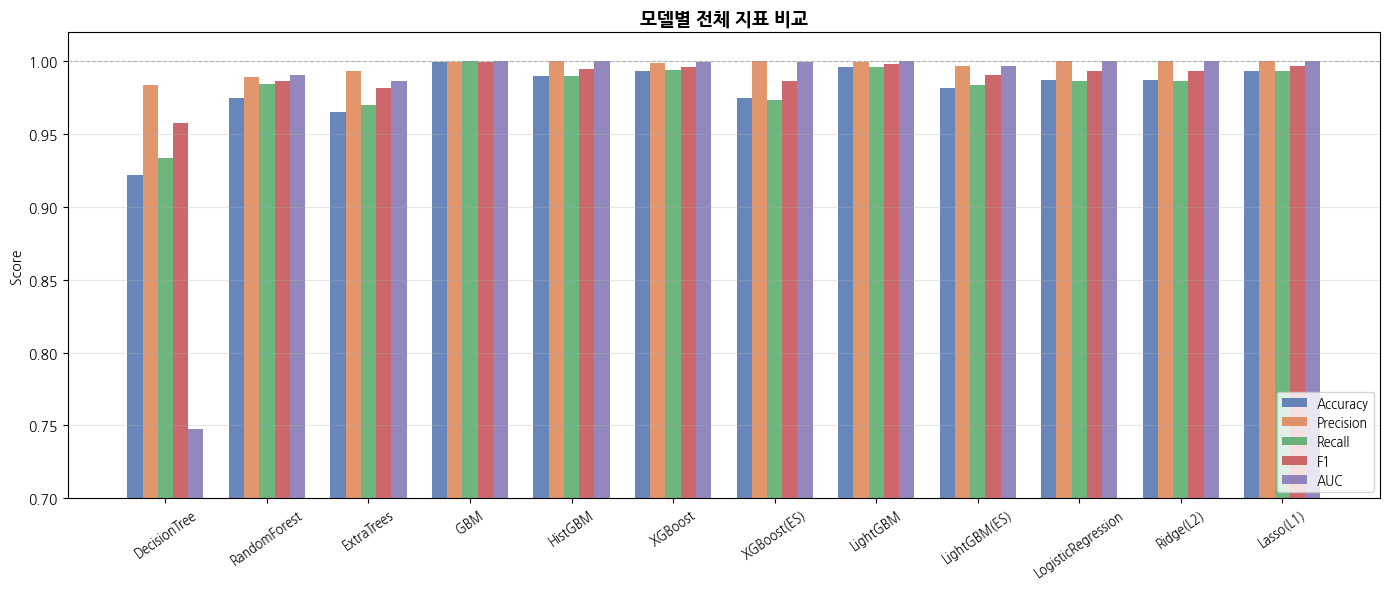

viz_01_all_metrics.png 저장 완료


In [38]:
# 그래프 설정
models    = df_result.index.tolist()
x         = np.arange(len(models))
bar_width = 0.15
colors    = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']

# 그래프 1: 5개 지표 전체 비교 (묶음 막대그래프)
fig, ax1 = plt.subplots(figsize=(14, 6))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax1.bar(x + i * bar_width, df_result[metric], bar_width,
            label=metric, color=color, alpha=0.85)

ax1.set_title('모델별 전체 지표 비교', fontsize=13, fontweight='bold')
ax1.set_xticks(x + bar_width * 2)
ax1.set_xticklabels(models, rotation=35, ha='center', fontsize=9)
ax1.set_ylim(0.7, 1.02)
ax1.set_ylabel('Score')
ax1.legend(loc='lower right', fontsize=9)
ax1.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('viz_01_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print('viz_01_all_metrics.png 저장 완료')

##### 3-2-2. 시각화 - XGBoost vs RandomForest

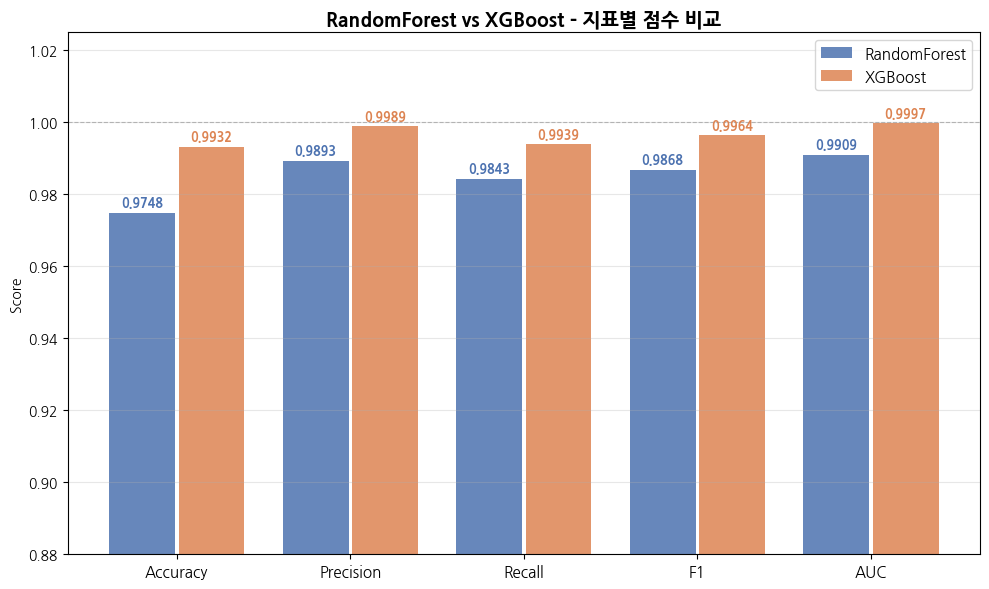

compare_01_metrics.png 저장 완료


In [39]:
# ================================================================
# XGBoost vs RandomForest 비교 시각화
# ================================================================

# ── 공통 설정 ─────────────────────────────────────────────────
COLOR_RF  = '#4C72B0'   # RandomForest 색상
COLOR_XGB = '#DD8452'   # XGBoost 색상

# ================================================================
# 비교 1: 지표별 점수 비교
# ================================================================
metrics      = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
rf_scores    = [
    accuracy_score(y_test,  rf_pred),
    precision_score(y_test, rf_pred,   zero_division=0),
    recall_score(y_test,    rf_pred,   zero_division=0),
    f1_score(y_test,        rf_pred,   zero_division=0),
    roc_auc_score(y_test,   rf_pred_proba)
]
xgb_scores  = [
    accuracy_score(y_test,  xgb_pred),
    precision_score(y_test, xgb_pred, zero_division=0),
    recall_score(y_test,    xgb_pred, zero_division=0),
    f1_score(y_test,        xgb_pred, zero_division=0),
    roc_auc_score(y_test,   xgb_pred_proba)
]

x = np.arange(len(metrics))
fig, ax = plt.subplots(figsize=(10, 6))

bars_rf  = ax.bar(x - 0.2, rf_scores,  0.38, label='RandomForest', color=COLOR_RF,  alpha=0.85)
bars_xgb = ax.bar(x + 0.2, xgb_scores, 0.38, label='XGBoost',      color=COLOR_XGB, alpha=0.85)

for bar, val in zip(bars_rf, rf_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, color=COLOR_RF, fontweight='bold')

for bar, val in zip(bars_xgb, xgb_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, color=COLOR_XGB, fontweight='bold')

ax.set_title('RandomForest vs XGBoost - 지표별 점수 비교', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.88, 1.025)
ax.set_ylabel('Score')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('compare_01_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print('compare_01_metrics.png 저장 완료')

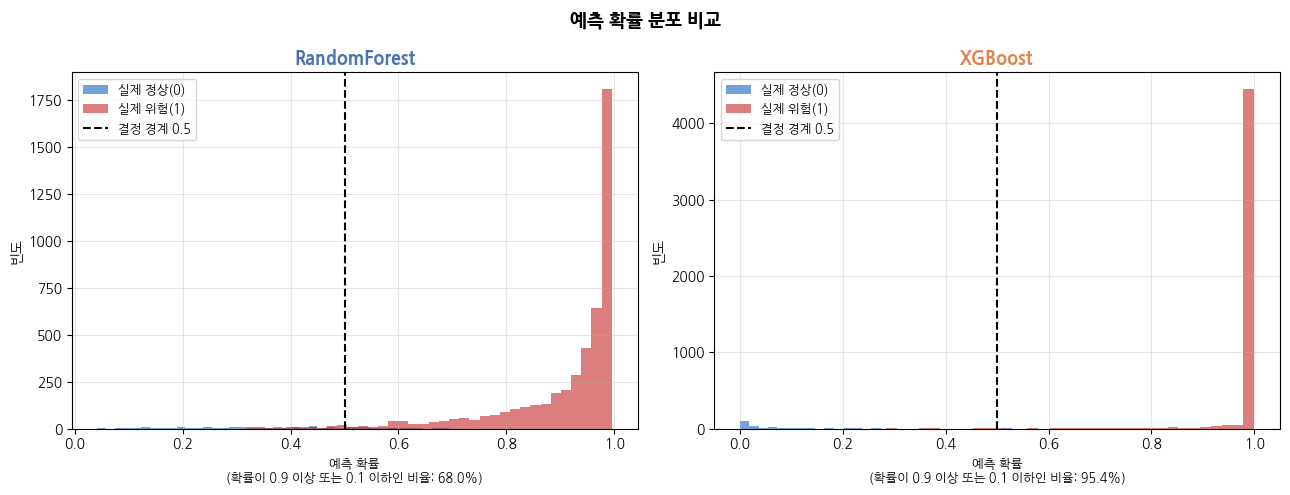

compare_05_prob_dist.png 저장 완료

RandomForest 극단 확률 비율: 68.0%
XGBoost      극단 확률 비율: 95.4%
→ 비율이 낮을수록 더 현실적인 확률 예측을 하는 모델


In [40]:
# ================================================================
# 비교 2: 예측 확률 분포 비교
# ================================================================
# 모델이 예측할 때 얼마나 확신하는지를 보여줌
# 과적합/과최적화된 모델일수록 0 또는 1에 극단적으로 몰림
# 신뢰할 수 있는 모델일수록 중간값도 존재하며 자연스러운 분포를 보임

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('예측 확률 분포 비교',
             fontsize=13, fontweight='bold')

for ax, proba, title, color in zip(
        axes,
        [rf_pred_proba, xgb_pred_proba],
        ['RandomForest', 'XGBoost'],
        [COLOR_RF, COLOR_XGB]):

    # 실제 정상(0)과 위험(1) 분리해서 표시
    proba_0 = proba[y_test == 0]
    proba_1 = proba[y_test == 1]

    ax.hist(proba_0, bins=40, alpha=0.6, color='#1565C0', label='실제 정상(0)')
    ax.hist(proba_1, bins=40, alpha=0.6, color='#C62828', label='실제 위험(1)')
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='결정 경계 0.5')

    ax.set_title(title, fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel('예측 확률')
    ax.set_ylabel('빈도')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # 극단값(0.9 이상 또는 0.1 이하) 비율 계산
    extreme_ratio = ((proba >= 0.9) | (proba <= 0.1)).mean() * 100
    ax.set_xlabel(f'예측 확률\n(확률이 0.9 이상 또는 0.1 이하인 비율: {extreme_ratio:.1f}%)',
                  fontsize=9)

plt.tight_layout()
plt.savefig('compare_05_prob_dist.png', dpi=300, bbox_inches='tight')
plt.show()
print('compare_05_prob_dist.png 저장 완료')
print()
rf_extreme  = ((rf_pred_proba >= 0.9)  | (rf_pred_proba  <= 0.1)).mean() * 100
xgb_extreme = ((xgb_pred_proba >= 0.9) | (xgb_pred_proba <= 0.1)).mean() * 100
print(f'RandomForest 극단 확률 비율: {rf_extreme:.1f}%')
print(f'XGBoost      극단 확률 비율: {xgb_extreme:.1f}%')
print('→ 비율이 낮을수록 더 현실적인 확률 예측을 하는 모델')

# 4. 최적 모델 - Random Forest

### 4-1. 모델 분석 - 시각화

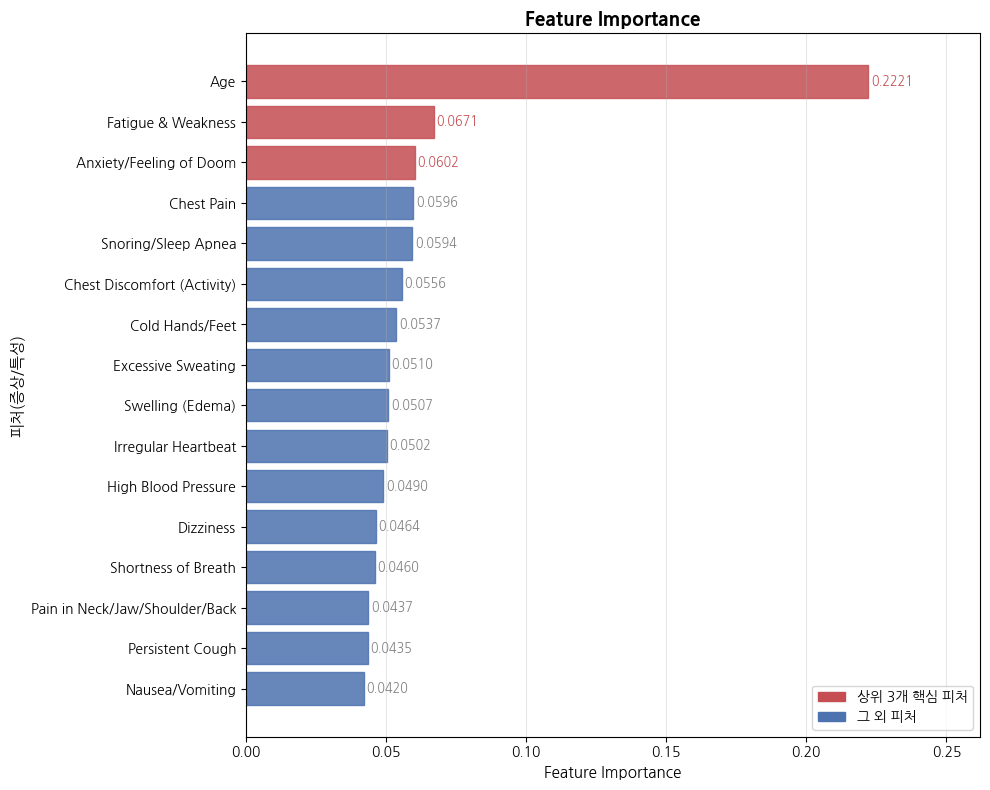

rf_01_feature_importance.png 저장 완료

=== Feature Importance 순위 ===
 1위  Age                                 0.2221 ★
 2위  Fatigue & Weakness                  0.0671 ★
 3위  Anxiety/Feeling of Doom             0.0602 ★
 4위  Chest Pain                          0.0596
 5위  Snoring/Sleep Apnea                 0.0594
 6위  Chest Discomfort (Activity)         0.0556
 7위  Cold Hands/Feet                     0.0537
 8위  Excessive Sweating                  0.0510
 9위  Swelling (Edema)                    0.0507
10위  Irregular Heartbeat                 0.0502
11위  High Blood Pressure                 0.0490
12위  Dizziness                           0.0464
13위  Shortness of Breath                 0.0460
14위  Pain in Neck/Jaw/Shoulder/Back      0.0437
15위  Persistent Cough                    0.0435
16위  Nausea/Vomiting                     0.0420


In [41]:
COLOR_MAIN = '#4C72B0'   # RandomForest 대표 색상

# ================================================================
# 1. Feature Importance
# ================================================================
feature_names      = X_feature.columns.tolist()
importances        = rf.feature_importances_
importance_series  = pd.Series(importances, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(importance_series.index, importance_series.values,
               color=COLOR_MAIN, alpha=0.85, edgecolor='white')

# 가장 중요한 피처 강조 (상위 3개)
top3_idx = importance_series.nlargest(3).index
for bar, name in zip(bars, importance_series.index):
    color = '#C44E52' if name in top3_idx else COLOR_MAIN
    bar.set_color(color)
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.4f}',
            va='center', fontsize=9,
            color='#C44E52' if name in top3_idx else 'gray')

ax.set_title('Feature Importance',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_ylabel('피처(증상/특성)', fontsize=11)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, importance_series.max() * 1.18)

# 범례
red_patch   = mpatches.Patch(color='#C44E52', label='상위 3개 핵심 피처')
blue_patch  = mpatches.Patch(color=COLOR_MAIN, label='그 외 피처')
ax.legend(handles=[red_patch, blue_patch], fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig('rf_01_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print('rf_01_feature_importance.png 저장 완료')

print('\n=== Feature Importance 순위 ===')
for rank, (name, val) in enumerate(importance_series.sort_values(ascending=False).items(), 1):
    marker = ' ★' if rank <= 3 else ''
    print(f'{rank:2d}위  {name:35s} {val:.4f}{marker}')

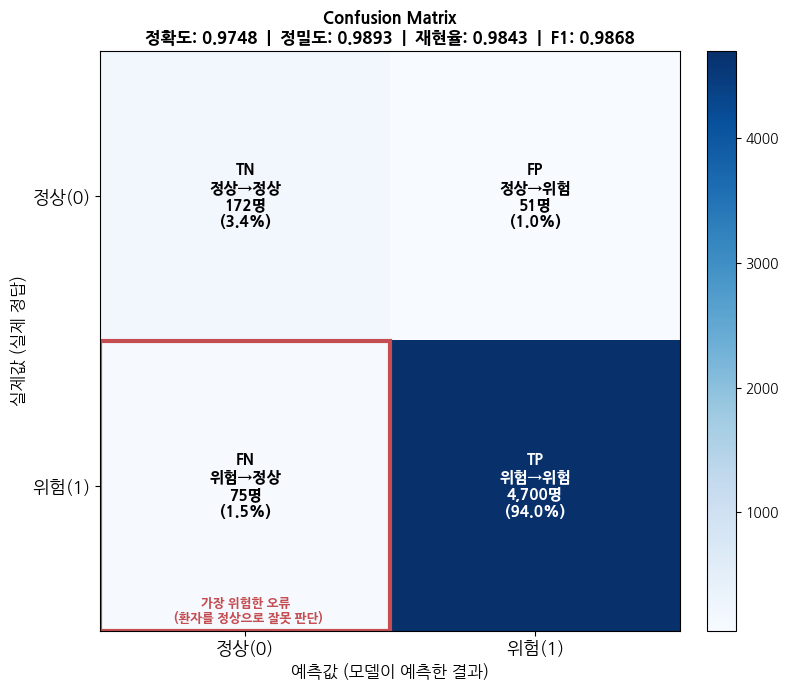

rf_03_confusion_matrix.png 저장 완료

=== Confusion Matrix 해석 ===
TN (정상 → 정상) : 172명  정상 환자를 정상으로 올바르게 예측
FP (정상 → 위험) : 51명  정상 환자를 위험으로 잘못 예측
FN (위험 → 정상) : 75명  위험 환자를 정상으로 잘못 예측 ← 가장 위험
TP (위험 → 위험) : 4,700명  위험 환자를 위험으로 올바르게 예측

총 75명의 위험 환자를 놓쳤으며, 이는 전체 위험군의 1.57%에 해당합니다.


In [42]:
# ================================================================
# 2. Confusion Matrix
# ================================================================
cm = confusion_matrix(y_test, rf_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

labels = ['정상(0)', '위험(1)']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels, fontsize=13)
ax.set_yticklabels(labels, fontsize=13)
ax.set_xlabel('예측값 (모델이 예측한 결과)', fontsize=12)
ax.set_ylabel('실제값 (실제 정답)', fontsize=12)

# 각 칸에 수치 + 설명 표시
cell_info = [
    (0, 0, tn, 'TN\n정상→정상'),
    (0, 1, fp, 'FP\n정상→위험'),
    (1, 0, fn, 'FN\n위험→정상'),
    (1, 1, tp, 'TP\n위험→위험'),
]

thresh = cm.max() / 2
for i, j, val, label in cell_info:
    text_color = 'white' if cm[i, j] > thresh else 'black'
    ax.text(j, i,
            f'{label}\n{val:,}명\n({val/cm.sum()*100:.1f}%)',
            ha='center', va='center', fontsize=11,
            color=text_color, fontweight='bold')

# 핵심 지표 표시
accuracy  = accuracy_score(y_test, rf_pred)
precision = precision_score(y_test, rf_pred)
recall    = recall_score(y_test, rf_pred)
f1        = f1_score(y_test, rf_pred)

ax.set_title(
    f'Confusion Matrix\n'
    f'정확도: {accuracy:.4f}  |  정밀도: {precision:.4f}  |  재현율: {recall:.4f}  |  F1: {f1:.4f}',
    fontsize=12, fontweight='bold')

# FN 강조 설명
ax.add_patch(plt.Rectangle((-0.5, 0.5), 1, 1,
             fill=False, edgecolor='#C44E52', linewidth=3))
ax.text(0, 1.47, '가장 위험한 오류\n  (환자를 정상으로 잘못 판단)',
        ha='center', fontsize=9, color='#C44E52', fontweight='bold')

plt.tight_layout()
plt.savefig('rf_03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('rf_03_confusion_matrix.png 저장 완료')

# 최종 수치 요약
print('\n=== Confusion Matrix 해석 ===')
print(f'TN (정상 → 정상) : {tn:,}명  정상 환자를 정상으로 올바르게 예측')
print(f'FP (정상 → 위험) : {fp:,}명  정상 환자를 위험으로 잘못 예측')
print(f'FN (위험 → 정상) : {fn:,}명  위험 환자를 정상으로 잘못 예측 ← 가장 위험')
print(f'TP (위험 → 위험) : {tp:,}명  위험 환자를 위험으로 올바르게 예측')
print(f'\n총 {fn:,}명의 위험 환자를 놓쳤으며, 이는 전체 위험군의 {fn/(fn+tp)*100:.2f}%에 해당합니다.')


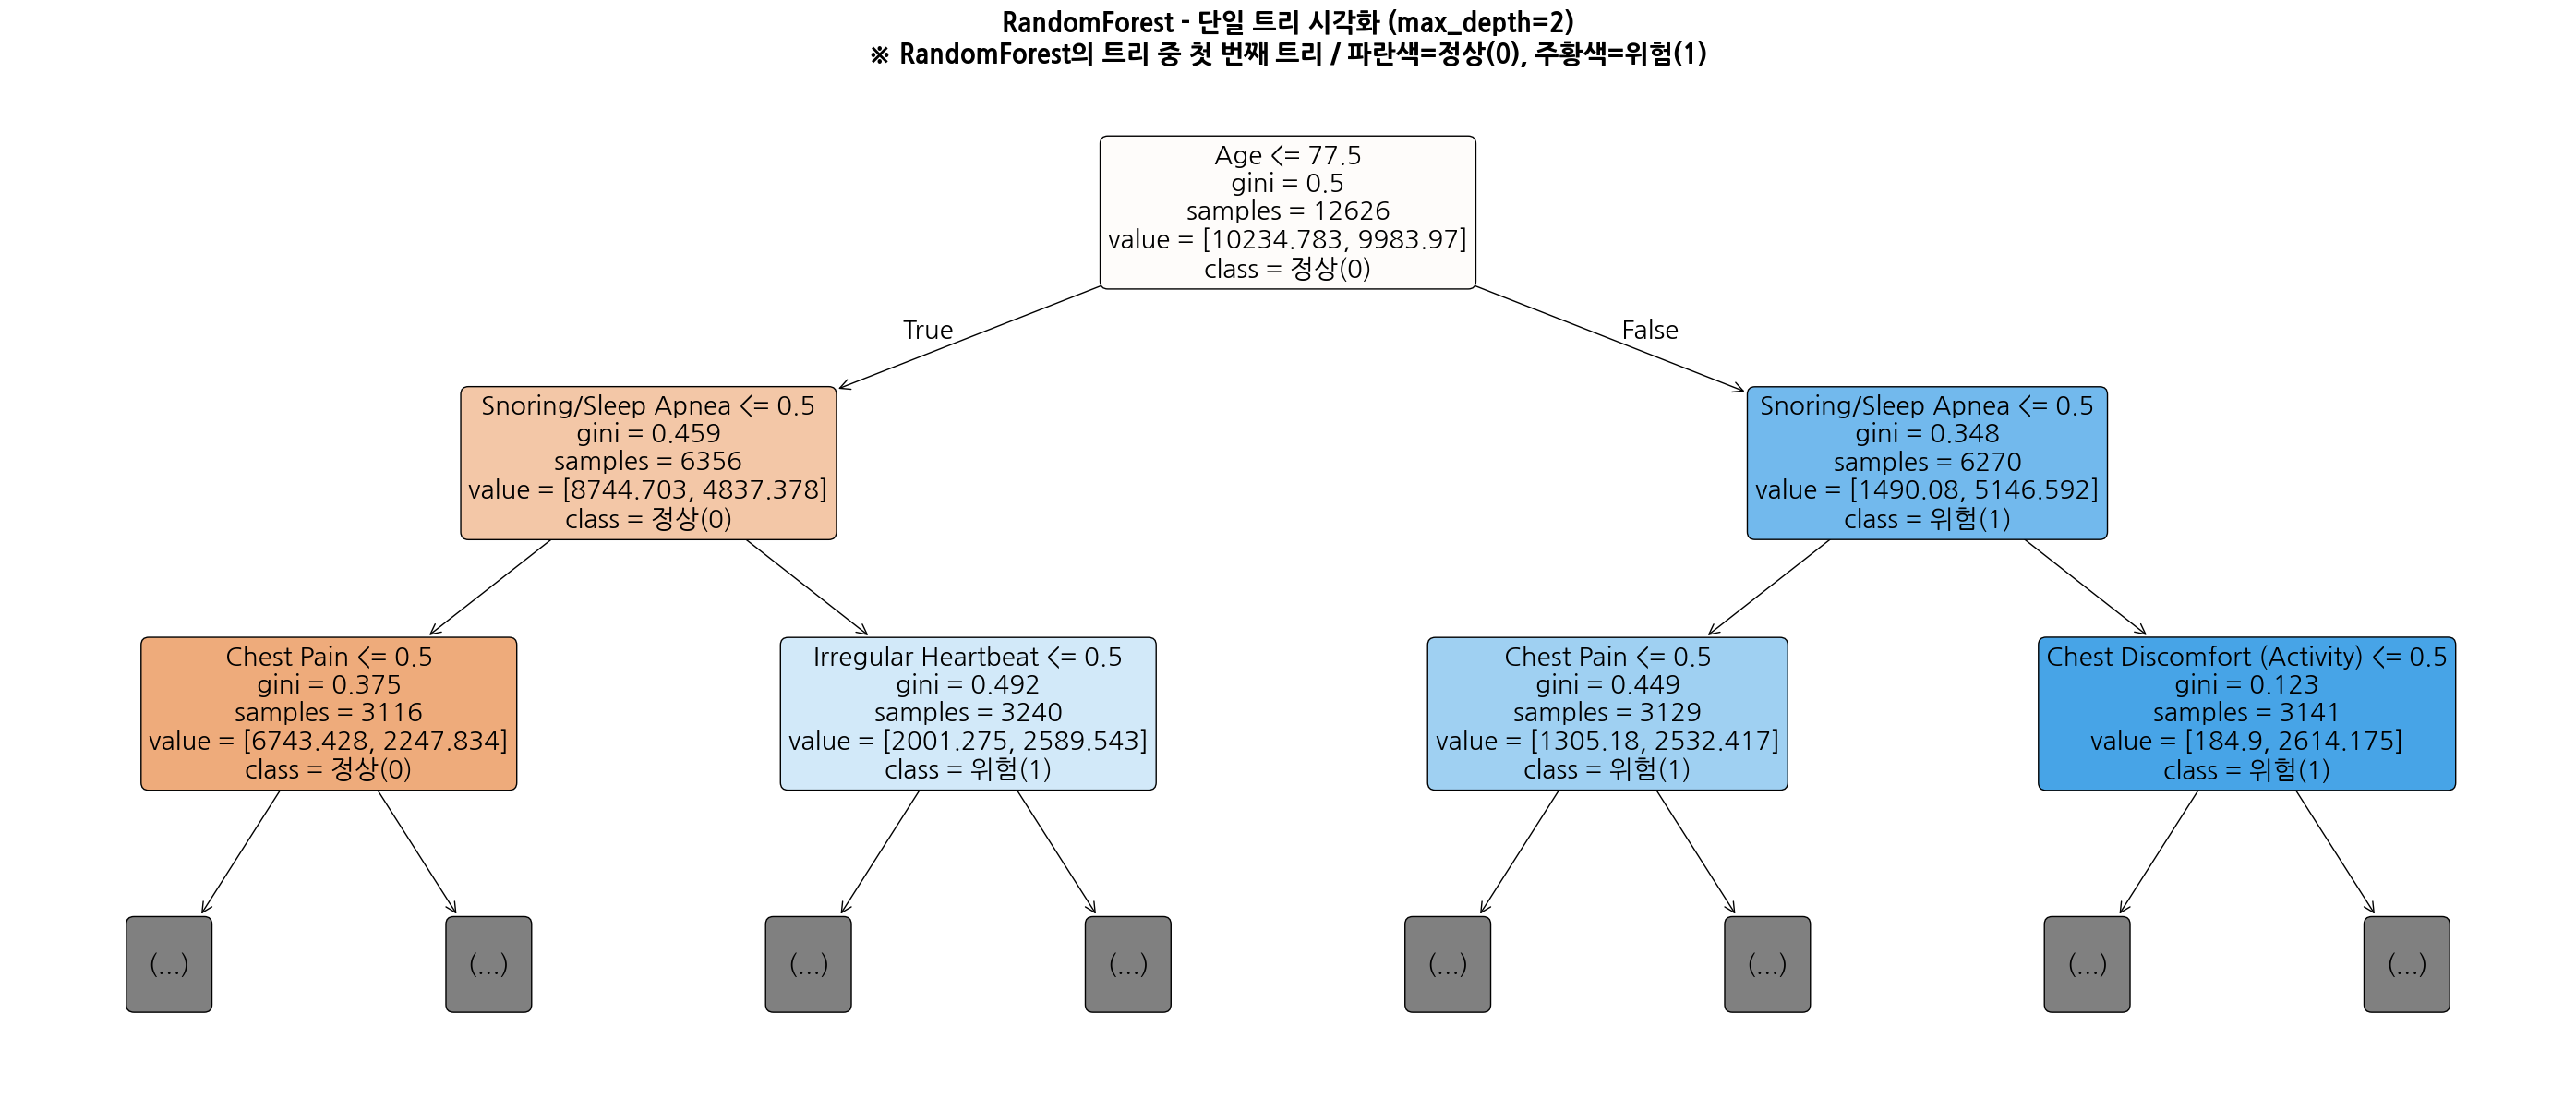

rf_04_single_tree.png 저장 완료


In [43]:
# ================================================================
# 3. 단일 트리 시각화 (depth=2)
# ================================================================

# RandomForest에서 첫 번째 트리 추출
single_tree = rf.estimators_[0]

fig, ax = plt.subplots(figsize=(28, 12))
plot_tree(
    single_tree,
    max_depth=2,                          # depth 2로 제한
    feature_names=X_feature.columns,     # 피처 이름 표시
    class_names=['정상(0)', '위험(1)'],   # 클래스 이름 표시
    filled=True,                          # 클래스별 색상 채우기
    rounded=True,                         # 모서리 둥글게
    fontsize=20,
    ax=ax,
    impurity=True,                        # 불순도(gini) 표시
    proportion=False                      # 실제 샘플 수 표시
)

ax.set_title(
    'RandomForest - 단일 트리 시각화 (max_depth=2)\n'
    '※ RandomForest의 트리 중 첫 번째 트리 / 파란색=정상(0), 주황색=위험(1)',
    fontsize=20, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('rf_04_single_tree.png', dpi=300, bbox_inches='tight')
plt.show()
print('rf_04_single_tree.png 저장 완료')

### 4-2. 가상 데이터 예측

In [44]:
# 가상 데이터 생성
person_data = [[1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 75],   # 가상 인물 A (고위험)
               [0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 67]]   # 가상 인물 B (저위험)

# 예측
pred = rf.predict(person_data)
#print(pred)
# -> array([1, 0])
# pred[0]=1(인물A) / pred[1]=0(인물B)
pred_proba = rf.predict_proba(person_data)
#print(pred_proba)
#-> array([[0.00837305 0.99162695], [0.80658479 0.19341521]])

print(f'인물 A 예측 결과: {"위험 (1)" if pred[0] == 1 else "정상 (0)"}') # pred[0]==1 이면 위험(1) 출력
print(f'인물 A 정상 확률: {pred_proba[0][0]*100:.2f}%, 위험 확률: {pred_proba[0][1]*100:.2f}%')
print()
print(f'인물 B 예측 결과: {"위험 (1)" if pred[1] == 1 else "정상 (0)"}')
print(f'인물 B 정상 확률: {pred_proba[1][0]*100:.2f}%, 위험 확률: {pred_proba[1][1]*100:.2f}%')

인물 A 예측 결과: 위험 (1)
인물 A 정상 확률: 0.84%, 위험 확률: 99.16%

인물 B 예측 결과: 정상 (0)
인물 B 정상 확률: 80.66%, 위험 확률: 19.34%
